In [1]:
%load_ext autoreload
%autoreload 2

import re
import numpy as np
import pandas as pd
import scipy.sparse
from statsmodels.stats.multitest import multipletests
import scanpy as sc
import seaborn as sns   
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import gc
import warnings
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.insert(0, '/home/gdallagl/myworkdir/XDP/script/NucSeq/de-repression/')

In [2]:
SAMPLE_VARIABLE  = "donor_id"
AGE              = "age"
ZONE_COL         = "zone"
LIBRARY_SIZE_COL = "total_counts"
CONDITION        = "condition"
HEALTHY_CONDITION    = "healthy"
DISEASED_CONDITION    = "diseased"
ZONE_COL = "zone"

# BICAN - Cocariates for determining G (gene of derepsse gene in bican -H)
COVARIATE_COLS = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5"] # in addtion to mean log umi and squared version



# Load Bican (D1 Matrix)

In [3]:
BICAN_PATH = "/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix/d1_cleaner_v3_raw_dv_wm_labeled.h5ad"

bican = sc.read_h5ad(BICAN_PATH)

print(bican.X[:100, :100].toarray().sum(axis=1))

# bican.X = bican.layers["counts"].astype("int32", copy=False)

# Rename columns to a consistent naming convention
bican.obs = bican.obs.rename(columns={
    "merge_step_6" : ZONE_COL,
    "donor_id"     : SAMPLE_VARIABLE,
    "age"          : AGE,
    "n_counts"     : LIBRARY_SIZE_COL,
    "imputed_sex"  : "sex",
})
# ATTENTION: all healthy
bican.obs[CONDITION] = HEALTHY_CONDITION

# gene are gene_symbols

print(bican)
print(f"\nDonors : {bican.obs[SAMPLE_VARIABLE].nunique()}")
print(f"Zones  : {sorted(bican.obs[ZONE_COL].unique())}")
print(f"Age range: {bican.obs[AGE].min():.0f}–{bican.obs[AGE].max():.0f}")

[419. 538. 632. 748. 380. 255. 576. 895. 519. 530. 474. 591. 524. 560.
 491. 580. 183. 427. 711. 780. 710. 447. 695. 621. 645. 700. 640. 509.
 467. 595. 484. 501. 610. 626. 406. 639. 609. 377. 600. 598. 792. 605.
 676. 475. 529. 581. 644. 458. 634. 665. 611. 611. 500. 471. 485. 632.
 649. 809. 319. 435. 851. 452. 596. 433. 607. 399. 212. 633. 631. 661.
 668. 426. 495. 710. 362. 711. 484. 721. 607. 197. 494. 721. 467. 886.
 550. 769. 344. 453. 874. 571. 441. 246. 397. 528. 551. 311. 548. 568.
 539. 552.]
AnnData object with n_obs × n_vars = 206571 × 38100
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete'

In [4]:
# ATTENTION: PCs are SNP
bican[bican.obs[SAMPLE_VARIABLE] == "MS652464"].obs.PC1

v12_10X-GEMX-3P_CaH_CTGCAAATCGTGCCTC        -0.0105
v12_10X-GEMX-3P_CaH_CGTTCAGGTCCATTAA        -0.0105
v12_10X-GEMX-3P_CaH_ATAGGCCTCCTCAGCC        -0.0105
v12_10X-GEMX-3P_CaH_TCATTCGCAACTGTCC        -0.0105
v12_10X-GEMX-3P_CaH_CAATTGGTCTGGTAAT        -0.0105
                                              ...  
v67_10X-GEMX-3P_NAC_rxn4_CTTACTATCCGCGACA   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_GCTACTGGTCTAGGCC   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_TAAGCGGAGGTCAAGG   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_GCCATTCCATCGTTGC   -0.0105
v67_10X-GEMX-3P_NAC_rxn4_CGTCAAATCCATGTGA   -0.0105
Name: PC1, Length: 658, dtype: float64

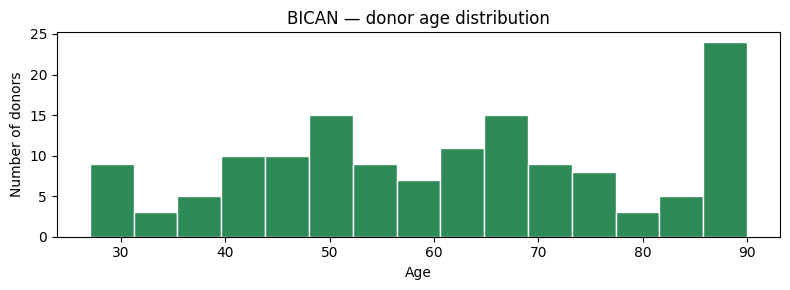

In [5]:
import matplotlib.pyplot as plt


# Quick overview of donor ages across the full dataset
donor_meta = bican.obs.drop_duplicates(SAMPLE_VARIABLE)[[SAMPLE_VARIABLE, AGE]].copy()
donor_meta[AGE] = donor_meta[AGE].astype(float)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(donor_meta[AGE], bins=15, color="seagreen", edgecolor="white")
ax.set_xlabel("Age")
ax.set_ylabel("Number of donors")
ax.set_title("BICAN — donor age distribution")
plt.tight_layout()
plt.show()

# Bican H - Analysis

### Remove useless genes

In [6]:
# remove bad genes
BAD_PREFIXES = ("MT-", "MTRNR", "RPL", "RPS", "HBB", "HBA", "HBG", "HBD", "HBE", "HBZ", "ENSG")
def filter_bad_genes(adata):
    keep = [not any(g.upper().startswith(p) for p in BAD_PREFIXES) for g in adata.var_names]
    return adata[:, keep].copy()

print(bican)
bican = filter_bad_genes(bican) 
print(bican)

AnnData object with n_obs × n_vars = 206571 × 38100
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred_caudate_spn_mp_max_prob', 'scpred_c

### Check fraaction of zones-cells per donor

in futue dont want that a zone dominates over the otehrs

In [7]:
#one 4 has 39% of cells per donor on average
#Zone 4 contributes almost 40% of the signal in the GLM. G is biased toward zone-4-driven genes.

cells_pz = bican.obs.groupby([SAMPLE_VARIABLE, ZONE_COL]).size().unstack(fill_value=0)
frac_pz  = cells_pz.div(cells_pz.sum(axis=1), axis=0)   # fraction of each donor's cells per zone

frac_pz.mean().rename("mean cell fraction").to_frame()   # if zone 4 >> others → it dominates DR



/tmp/ipykernel_166770/3204341158.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_pz = bican.obs.groupby([SAMPLE_VARIABLE, ZONE_COL]).size().unstack(fill_value=0)


,mean cell fraction
zone,
1,0.136302
2,0.159094
3,0.143999
4,0.390540
5,0.115053
6,0.055013


### Create a sample level df with covs

In [75]:
# are skewed donors systematically older?
zone4_frac = (
    bican.obs.groupby(SAMPLE_VARIABLE)[ZONE_COL]
    .apply(lambda x: (x == 4).mean())
)
age_per_donor = bican.obs.drop_duplicates(SAMPLE_VARIABLE).set_index(SAMPLE_VARIABLE)[AGE]
n_valid_zones = (
    bican.obs.groupby([SAMPLE_VARIABLE, ZONE_COL]).size()
    .unstack(fill_value=0).gt(30).sum(axis=1)
    .rename("n_valid_zones")
)
df = pd.concat([zone4_frac, age_per_donor, n_valid_zones], axis=1)

# donors that would be excluded by min_zones=3
min_zones=5
excluded = df[df["n_valid_zones"] < min_zones]
included = df[df["n_valid_zones"] >= min_zones]
print(f"Excluded: n={len(excluded)}, mean age={excluded[AGE].mean():.1f}")
print(f"Included: n={len(included)}, mean age={included[AGE].mean():.1f}")


Excluded: n=44, mean age=58.5
Included: n=99, mean age=62.7


/tmp/ipykernel_166770/3094808996.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bican.obs.groupby(SAMPLE_VARIABLE)[ZONE_COL]
/tmp/ipykernel_166770/3094808996.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bican.obs.groupby([SAMPLE_VARIABLE, ZONE_COL]).size()


In [ ]:
def build_sample_df(adata, sample_col, meta_cols, min_cells=30, zone_col=None, min_zones=6):
    # computes everything about samples in one place:
    # meta_cols are pulled from adata.obs as-is (age, zone, sex, PC1-5, ...)
    # derived covariates (meanLogUMI, log_n_cells, ...) are computed from counts
    # returns sample_df (samples x all covariates), dr_df (samples x genes), k_df (samples x genes)
    #
    # zone_col: if provided, DR is averaged equally across zones (zone-balanced)
    #           this prevents zones with more cells (e.g. zone 4 ~39%) from dominating
    #           if None, DR is pooled across all cells of the donor (original behaviour)
    X = adata.X
    rows, dr_rows, k_rows = {}, {}, {}

    for s in adata.obs[sample_col].unique():
        idx = np.where(adata.obs[sample_col] == s)[0]
        if len(idx) < min_cells:
            continue

        Xs           = X[idx].toarray() if sp.issparse(X) else X[idx]
        n            = len(idx)
        cell_umi     = Xs.sum(axis=1)                       # total UMI per cell
        mean_log_umi = float(np.log1p(cell_umi).mean())     # mean log UMI across cells

        row                = adata.obs.iloc[idx][meta_cols].iloc[0].to_dict()   # donor-level meta (constant within sample)
        row["meanLogUMI"]  = mean_log_umi
        row["meanLogUMI2"] = mean_log_umi ** 2              # quadratic UMI term
        row["log_n_cells"] = float(np.log(n))               # proxy for capture quality
        row["median_UMI"]  = float(np.median(cell_umi))     # used later for zone OLS
        row["n_cells"]     = n

        if zone_col is not None:
            # The goal of zone-balanced DR is: for each donor, compute DR separately in each zone, then average equally across zones. This only makes sense if a donor actually has cells in multiple zone
            # zone-balanced DR: compute DR per zone then average across zones with equal weight
            # avoids high-cell-count zones dominating
            # remove the sample if it doesn't have enough zones →
            # donors with skewed zone distribution (e.g. 96% Zone 4) would contribute
            # only single-zone signal, defeating the purpose of zone-balancing
            zone_labels  = adata.obs.iloc[idx][zone_col].values
            zone_dr_list = []
            for z in np.unique(zone_labels):
                z_mask = zone_labels == z
                if z_mask.sum() < min_cells:
                    continue                                 # skip zones with too few cells
                zone_dr_list.append((Xs[z_mask] > 0).mean(axis=0))   # DR for this zone

            if len(zone_dr_list) < min_zones:               # skip donor — too few zones to balance
                continue
            dr_balanced = np.mean(zone_dr_list, axis=0)     # equal weight per zone
        else:
            dr_balanced = (Xs > 0).sum(axis=0) / n          # pooled DR across all cells (original behaviour)

        dr_rows[s] = dr_balanced                            # detection rate per gene
        k_rows[s]  = dr_balanced * n                        # pseudo-k for quasi-binomial GLM
        # NOTE: with zone_col, k is a float pseudo-count (DR_balanced × n_total), not a true integer count
        #       quasi-binomial (scale="X2") remains valid — it only uses mean-variance relationship

        rows[s] = row

    genes     = adata.var_names
    sample_df = pd.DataFrame(rows).T.apply(lambda col: pd.to_numeric(col, errors="coerce").fillna(col))
    dr_df     = pd.DataFrame(dr_rows, index=genes).T.astype(float)
    k_df      = pd.DataFrame(k_rows,  index=genes).T.astype(float)
    return sample_df, dr_df, k_df


MIN_CELL_PER_SAMPLE = 30
sample_df, dr_df, k_df = build_sample_df(
    bican, SAMPLE_VARIABLE, COVARIATE_COLS + [AGE],
    min_cells=MIN_CELL_PER_SAMPLE,
    zone_col=ZONE_COL,
    min_zones=3,   # require ≥30 cells in at least 3 zones — excludes skewed donors
)


KeyboardInterrupt: 

In [9]:
display(sample_df), display(dr_df), display(k_df)

,sex,PC1,PC2,PC3,PC4,PC5,age,meanLogUMI,meanLogUMI2,log_n_cells,median_UMI,n_cells
MS652464,2.0,-0.0105,-0.0228,0.0033,0.0152,0.0020,70.0,11.108012,123.387927,6.489205,74467.0,658.0
MD6571,1.0,-0.0077,-0.0101,0.0216,-0.0080,0.0003,43.0,11.091708,123.025977,6.282267,75972.0,535.0
MS323252,1.0,-0.0088,-0.0215,-0.0003,0.0150,0.0007,90.0,11.135519,123.999781,7.822445,73750.0,2496.0
MD6666,1.0,0.0236,-0.0006,0.0003,0.0010,0.0075,29.0,11.478922,131.765647,7.211557,107720.0,1355.0
MS272264,2.0,-0.0107,0.0007,-0.0251,-0.0175,-0.0005,74.0,11.230624,126.126904,7.059618,80784.5,1164.0
...,...,...,...,...,...,...,...,...,...,...,...,...
MD6471,2.0,-0.0105,-0.0234,0.0039,0.0166,0.0003,49.0,11.340837,128.614588,7.204149,91471.0,1345.0
PT13641,2.0,0.0221,-0.0013,0.0005,0.0018,0.0056,42.0,11.238673,126.307772,6.739337,80495.0,845.0
MD6432,2.0,0.0203,-0.0023,0.0009,0.0034,0.0068,28.0,11.471981,131.606343,7.511525,100498.0,1829.0
PT13702,2.0,-0.0104,-0.0236,0.0034,0.0166,0.0010,41.0,11.143919,124.186932,6.639876,68868.0,765.0


gene_symbol,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,LINC01347,FAM86DP,SOD2,SMG1P7,SMG1P5,ANKRD20A11P,COL6A4P1,PRSS30P,LY6S,TMEM276
MS652464,0.022939,0.000000,0.915331,0.548892,0.587051,0.014455,0.003593,0.199925,0.946952,0.343205,...,0.077045,0.307556,0.832130,0.371194,0.863439,0.896755,0.012571,0.008355,0.002279,0.324930
MD6571,0.011282,0.000000,0.895759,0.608337,0.622402,0.003413,0.018961,0.286069,0.981039,0.414231,...,0.108243,0.466888,0.893411,0.306789,0.878176,0.512995,0.015050,0.013576,0.001706,0.600211
MS323252,0.029673,0.001173,0.884277,0.566988,0.680296,0.015876,0.030800,0.295625,0.959914,0.330347,...,0.079137,0.554254,0.798159,0.263622,0.883847,0.867551,0.014754,0.009760,0.009543,0.485627
MD6666,0.014870,0.000260,0.954132,0.710414,0.747011,0.013443,0.027342,0.353239,0.995071,0.417148,...,0.090985,0.588980,0.921134,0.348448,0.940908,0.970781,0.028298,0.005851,0.008420,0.585813
MS272264,0.024692,0.000977,0.915756,0.541246,0.432616,0.019416,0.017005,0.331257,0.963849,0.339935,...,0.091580,0.384796,0.839733,0.398475,0.880492,0.837367,0.013504,0.007747,0.009105,0.503967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MD6471,0.009242,0.000000,0.924306,0.674663,0.730356,0.014774,0.026781,0.392107,0.987464,0.390214,...,0.114591,0.410192,0.906405,0.315547,0.910319,0.997834,0.015073,0.027957,0.007639,0.650392
PT13641,0.005392,0.000000,0.906486,0.601652,0.606521,0.010783,0.039180,0.343412,0.961704,0.384814,...,0.125261,0.478823,0.857975,0.386589,0.904416,0.955197,0.026003,0.027964,0.006793,0.375478
MD6432,0.038391,0.000471,0.963479,0.731945,0.781632,0.008647,0.014599,0.367711,0.994019,0.512412,...,0.122701,0.651201,0.973295,0.417472,0.934679,0.999529,0.020106,0.028933,0.009765,0.411776
PT13702,0.013972,0.000000,0.900110,0.587317,0.783564,0.020310,0.012753,0.182607,0.976490,0.270507,...,0.074748,0.375541,0.784556,0.354931,0.916295,0.792656,0.011367,0.014017,0.002212,0.218875


gene_symbol,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,LINC01347,FAM86DP,SOD2,SMG1P7,SMG1P5,ANKRD20A11P,COL6A4P1,PRSS30P,LY6S,TMEM276
MS652464,15.093848,0.000000,602.287483,361.171047,386.279696,9.511239,2.364072,131.550445,623.094462,225.828702,...,50.695735,202.372136,547.541427,244.245546,568.142739,590.064735,8.271756,5.497674,1.499894,213.804174
MD6571,6.036000,0.000000,479.230856,325.460270,332.985313,1.825939,10.144361,153.046759,524.855639,221.613537,...,57.910047,249.784910,477.974887,164.132013,469.824303,274.452270,8.051707,7.263030,0.912969,321.112913
MS323252,74.064221,2.928798,2207.155181,1415.201129,1698.019919,39.625680,76.877687,737.878782,2395.945377,824.545753,...,197.526881,1383.417706,1992.204524,657.999797,2206.081911,2165.407586,36.825179,24.362022,23.818112,1212.125747
MD6666,20.148869,0.351948,1292.849321,962.610610,1012.200525,18.215782,37.048715,478.639185,1348.320896,565.234964,...,123.284735,798.067777,1248.136803,472.147000,1274.929818,1315.407963,38.343203,7.927454,11.409486,793.777090
MS272264,28.741522,1.137486,1065.940231,630.010429,503.564477,22.600627,19.793293,385.583688,1121.919858,395.684176,...,106.598939,447.902325,977.449183,463.825442,1024.892380,974.695260,15.719056,9.017101,10.598646,586.617109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MD6471,12.430353,0.000000,1243.191276,907.421424,982.328739,19.871493,36.021052,527.383441,1328.138935,524.837707,...,154.124564,551.707974,1219.114433,424.411258,1224.378786,1342.087178,20.273354,37.602478,10.274235,874.777669
PT13641,4.555909,0.000000,765.980743,508.396210,512.510470,9.111818,33.107431,290.182907,812.639686,325.167515,...,105.845654,404.605553,724.988997,326.667550,764.231214,807.141605,21.972187,23.629905,5.740408,317.278764
MD6432,70.216479,0.861111,1762.202639,1338.728233,1429.604441,15.815948,26.701559,672.544009,1818.060226,937.200705,...,224.420740,1191.046476,1780.156812,763.556685,1709.527683,1828.138889,36.773209,52.919158,17.860863,753.137628
PT13702,10.688841,0.000000,688.584099,449.297590,599.426108,15.536898,9.756001,139.694557,747.014699,206.938148,...,57.182508,287.288798,600.185261,271.522038,700.965418,606.382136,8.695478,10.722739,1.692478,167.439572


(None, None, None)

### Find derepressed genes

In [ ]:
# find derepressed genes
def find_derepressed_genes(sample_df, dr_df, k_df, age_col, glm_cov_cols, thr_dr, fdr_alpha=0.05):
    
    # split samples into Young (Q1) and Old (Q4) by age — Q2/Q3 are excluded
    age    = sample_df[age_col]
    q25, q75 = age.quantile(0.25), age.quantile(0.75)
    age_bin  = pd.Series(np.nan, index=sample_df.index)
    age_bin[age <= q25] = 0.0
    age_bin[age >= q75] = 1.0
 
    # Subsample to only include Young and Old samples
    keep    = age_bin.dropna().index
    age_bin = age_bin.loc[keep]
    dr_sub  = dr_df.loc[keep]
    k_sub   = k_df.loc[keep]

    # cell counts per sample, used as binomial n
    n_arr   = sample_df.loc[keep, "n_cells"].values.astype(float)
 
    y_idx     = age_bin[age_bin == 0].index   # sample ids for Young group
    o_idx     = age_bin[age_bin == 1].index
    mean_dr_Y = dr_sub.loc[y_idx].mean()      # mean DR per gene across Young donors
    mean_dr_O = dr_sub.loc[o_idx].mean()
 
    candidates = mean_dr_Y[mean_dr_Y < thr_dr].index.tolist()   # genes lowly expressed in Young
    print(candidates); print(len(candidates))
 
    # design matrix built once — only the binomial response [k, n-k] changes per gene
    exog = sm.add_constant(
        pd.concat([age_bin.rename("age_binary"), sample_df.loc[keep, glm_cov_cols]], axis=1).astype(float)
    )
    display(exog)
 
    records   = []
    separated = []   # genes with DR=0 in ALL Young and DR>0 in SOME Old — perfect separation, GLM beta diverges to +inf

    for gene in tqdm(candidates, desc="fitting GLM per gene"):

        # parameters for binomial GLM
        k_arr   = k_sub[gene].values.astype(float)          # the number of cells expressing this gene, per sample
        endog   = np.column_stack([k_arr, n_arr - k_arr])   # [cells expressing, cells not expressing]

        # check for perfect separation before fitting: all Young have k=0 AND some Old have k>0
        # in this case MLE diverges to +inf — the gene is real but GLM can't quantify it
        k_young = k_arr[age_bin.values == 0]
        k_old   = k_arr[age_bin.values == 1]
        if (k_young == 0).all() and (k_old > 0).any():
            separated.append(dict(
                gene      = gene,
                beta_age  = np.inf,           # signal is real but unquantifiable by MLE
                pval      = np.nan,           # no valid p-value from GLM — treated as significant by definition
                mean_dr_Y = mean_dr_Y[gene],
                mean_dr_O = mean_dr_O[gene],
            ))
            continue   # skip GLM for this gene — it would overflow and produce garbage coefficients

        try:
            # suppress the overflow and PerfectSeparationWarning — we already caught the clean cases above
            # residual warnings here are edge cases (e.g. near-separation) — skip them
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                warnings.simplefilter("ignore", sm.tools.sm_exceptions.PerfectSeparationWarning)

                # scale='X2' = quasi-binomial: inflates SE by sqrt(Pearson dispersion) when overdispersed
                # we need to pass n and k (not directly DR)
                res = sm.GLM(endog, exog, family=sm.families.Binomial()).fit(scale="X2", maxiter=100)

            # save results
            records.append(dict(
                gene      = gene,
                beta_age  = float(res.params["age_binary"]),
                pval      = float(res.pvalues["age_binary"]),
                mean_dr_Y = mean_dr_Y[gene],
                mean_dr_O = mean_dr_O[gene],
            ))

        except Exception as e:
            print(f"Error processing gene {gene}: {e}")

    res_df = pd.DataFrame(records)

    # adjust pvalues as we have multiple genes
    _, padj, _, _ = multipletests(res_df["pval"], method="fdr_bh", alpha=fdr_alpha)
    res_df["pval_adj"] = padj
 
    # save logFC between Y and O
    eps = 1e-4   # pseudocount to avoid log(0) when DR is exactly 0
    res_df["log2FC_DR"] = np.log2((res_df["mean_dr_O"] + eps) / (res_df["mean_dr_Y"] + eps))

    # same logFC for separated genes
    sep_df             = pd.DataFrame(separated)
    sep_df["pval_adj"] = np.nan   # no p-value — but these pass by definition
    sep_df["log2FC_DR"] = np.log2((sep_df["mean_dr_O"] + eps) / (sep_df["mean_dr_Y"] + eps))

    # derepressed = significant positive age effect AND lowly expressed in Young
    # lowly expressed in young we are already running test only on those
    G_glm = res_df[(res_df["pval_adj"] < fdr_alpha) & (res_df["beta_age"] > 0)]

    G_sep = sep_df[sep_df["mean_dr_O"] > 0.01]   # must be expressed in at least 1% of Old cells on average

    G = pd.concat([G_glm, G_sep], ignore_index=True)

    G = G[G["log2FC_DR"] > 0.5]    # at least ... increase in DR
    G = G[G["beta_age"] < 100]   # reasonable upper bound


    full_results = pd.concat([res_df, sep_df], ignore_index=True)
    full_results["overall_detect"] = (full_results["mean_dr_Y"] + full_results["mean_dr_O"]) / 2

    return G.sort_values("beta_age", ascending=False).reset_index(drop=True), full_results


THR_DR = 0.1
GLM_COV_COLS = ["sex", "PC1", "PC2", "PC3", "PC4", "PC5", "meanLogUMI", "meanLogUMI2", "log_n_cells"]
gene_derepressed, full_results = find_derepressed_genes(sample_df, dr_df, k_df, AGE, GLM_COV_COLS, THR_DR, 0.05)
display(gene_derepressed)

['TSPAN6', 'TNMD', 'FGR', 'CFH', 'HS3ST1', 'AOC1', 'WNT16', 'TMEM176A', 'CYP26B1', 'TFPI', 'PLXND1', 'CD38', 'HSPB6', 'PDK4', 'SLC22A16', 'ZMYND10', 'ABCB5', 'SLC4A1', 'CALCR', 'PRSS22', 'HOXA11', 'MEOX1', 'COPZ2', 'MPO', 'PON1', 'ABCB4', 'ASB4', 'TMEM98', 'YBX2', 'KRT33A', 'CACNA1G', 'TNFRSF12A', 'ALDH3B1', 'CCL26', 'USH1C', 'TBXA2R', 'LGALS14', 'ARSD', 'PRSS21', 'PROM1', 'CEACAM21', 'SLC13A2', 'CEACAM7', 'CD79B', 'SCN4A', 'TKTL1', 'PAX6', 'TEAD3', 'SELE', 'FMO3', 'NOX1', 'E2F2', 'TFAP2B', 'TFAP2D', 'PLEKHG6', 'NFIX', 'ST3GAL1', 'MMP25', 'IL32', 'PAX7', 'MASP2', 'IYD', 'TRAF3IP3', 'ETV7', 'CD9', 'HHATL', 'SEMA3G', 'STAB1', 'CD4', 'BTK', 'HFE', 'FMO1', 'SLC6A7', 'ANLN', 'DCN', 'TYROBP', 'CD22', 'SEMA3B', 'PRICKLE3', 'LTF', 'NR1H4', 'ALOX5', 'CLDN11', 'GPRC5A', 'CD6', 'ACP3', 'WAS', 'DPEP1', 'NPC1L1', 'IL20RA', 'CLCA1', 'CLCA4', 'IGF1', 'SLC38A5', 'SLC11A1', 'ATP1A2', 'VSIG2', 'MARCO', 'CYP24A1', 'SNAI2', 'CD74', 'HGF', 'ADGRA2', 'RUNX3', 'PLEKHB1', 'SERPINB1', 'C8B', 'EHD2', 'TYMP', 'V

,const,age_binary,sex,PC1,PC2,PC3,PC4,PC5,meanLogUMI,meanLogUMI2,log_n_cells
MD6571,1.0,0.0,1.0,-0.0077,-0.0101,0.0216,-0.0080,0.0003,11.091708,123.025977,6.282267
MS323252,1.0,1.0,1.0,-0.0088,-0.0215,-0.0003,0.0150,0.0007,11.135519,123.999781,7.822445
MD6666,1.0,0.0,1.0,0.0236,-0.0006,0.0003,0.0010,0.0075,11.478922,131.765647,7.211557
MS936039,1.0,1.0,2.0,-0.0100,-0.0235,0.0030,0.0179,0.0004,10.996858,120.930890,6.934397
MD6574,1.0,0.0,1.0,-0.0103,-0.0230,0.0042,0.0176,-0.0002,11.342950,128.662519,7.273093
...,...,...,...,...,...,...,...,...,...,...,...
MD6433,1.0,0.0,1.0,-0.0098,-0.0236,0.0040,0.0175,0.0003,11.592963,134.396787,6.549651
PT13641,1.0,0.0,2.0,0.0221,-0.0013,0.0005,0.0018,0.0056,11.238673,126.307772,6.739337
MD6432,1.0,0.0,2.0,0.0203,-0.0023,0.0009,0.0034,0.0068,11.471981,131.606343,7.511525
PT13702,1.0,0.0,2.0,-0.0104,-0.0236,0.0034,0.0166,0.0010,11.143919,124.186932,6.639876


fitting GLM per gene:   0%|          | 0/10752 [00:00<?, ?it/s]

,gene,beta_age,pval,mean_dr_Y,mean_dr_O,pval_adj,log2FC_DR
0,H2AB1,1.270791e+15,0.000000e+00,0.000009,0.000239,0.000000e+00,1.642016
1,IGLV2-14,1.741821e+02,0.000000e+00,0.000024,0.000201,0.000000e+00,1.278511
2,IGLV3-10,1.042739e+02,0.000000e+00,0.000012,0.000064,0.000000e+00,0.554262
3,IGHV2-5,8.274342e+01,0.000000e+00,0.000025,0.000095,0.000000e+00,0.646320
4,CGB3,4.597951e+01,0.000000e+00,0.000004,0.000052,0.000000e+00,0.545585
...,...,...,...,...,...,...,...
648,WASIR1,5.481034e-02,3.675264e-08,0.001142,0.001920,4.173043e-08,0.701295
649,HHLA3-AS1,5.319282e-02,8.721569e-13,0.001980,0.003049,1.016447e-12,0.598511
650,GFAP,5.027501e-02,1.764889e-15,0.035616,0.055479,2.084527e-15,0.637948
651,GDNF,4.253774e-02,1.048491e-10,0.020523,0.032633,1.208482e-10,0.666488


In [11]:
G = gene_derepressed["gene"].tolist()
print(f"{len(G)} derepressed genes found")

653 derepressed genes found


### Checj that foudn genes are not presnet in few zones

In [12]:
# for each zone, check what fraction of G genes increase in DR from Y to O
# dont waht that aingle zone drives genes
for zone in sorted(bican.obs[ZONE_COL].unique()):
    adata_z  = bican[bican.obs[ZONE_COL] == zone]
    sdf, ddf, _ = build_sample_df(adata_z, SAMPLE_VARIABLE,
                                  COVARIATE_COLS + [AGE], min_cells=MIN_CELL_PER_SAMPLE)
    age      = sdf[AGE]
    q25, q75 = age.quantile(0.25), age.quantile(0.75)
    y_idx    = sdf[age <= q25].index
    o_idx    = sdf[age >= q75].index
    dr_Y     = ddf.loc[y_idx, G].mean()
    dr_O     = ddf.loc[o_idx, G].mean()
    pct_up   = ((dr_O - dr_Y) > 0).mean()
    print(f"Zone {zone}: {pct_up:.1%} of G genes increase DR from Y to O")


Zone 1: 84.4% of G genes increase DR from Y to O
Zone 2: 82.7% of G genes increase DR from Y to O
Zone 3: 83.0% of G genes increase DR from Y to O
Zone 4: 83.6% of G genes increase DR from Y to O
Zone 5: 83.2% of G genes increase DR from Y to O
Zone 6: 76.6% of G genes increase DR from Y to O


### compute cell level and sample level derepression-program score

In [13]:
def compute_cell_score_count_ratio(adata, gene_list):
    present  = [g for g in gene_list if g in adata.var_names]              # drop genes absent from this adata
    gene_idx = [adata.var_names.get_loc(g) for g in present]               # column indices of program genes
    X        = adata.X
    total    = np.asarray(X.sum(axis=1)).flatten()                          # total UMI per cell across all genes
    program  = np.asarray(X[:, gene_idx].sum(axis=1)).flatten()            # UMI from program genes only
    return pd.Series(np.where(total > 0, program / total, 0.0), index=adata.obs_names)   # count ratio; 0 if cell has no counts

def add_program_score_per_sample(adata, sample_df, gene_list, sample_col, percentile=90):
    cell_scores          = compute_cell_score_count_ratio(adata, gene_list)   # count-ratio score for every cell
    adata.obs["_score"]  = cell_scores.values                     # store temporarily in obs for easy groupby
 
    for s in sample_df.index:
        mask                       = adata.obs[sample_col] == s                                              # cells belonging to this sample
        sample_df.loc[s, "score"]  = float(np.percentile(adata.obs.loc[mask, "_score"].values, percentile)) # 90th percentile captures the tail of highly expressing cells
 
    return sample_df

# ATTENTION: 
    # each sample doesnt have a "zone" cov --> only cells have it (cannot find sample levael aggregation)
    # we need thus to rcaltulate df_covs for each zone independlty

# ATTENTION
    # in addtion to be able to in futue compare results of model fitted on differt zones --> we need to normlaise age usong all zones splits
    # ATTENTION: this procedure is correct ONL for bicna becaseu ALL samples partccipates o all zones
    # beta_age = 0.02 means the same thing in zone 1 and zone 2: "+0.02 of the global score distribution per year". 

# Collect raw (unscaled) scores per zone
zone_sdfs = {}
for zone in sorted(bican.obs[ZONE_COL].unique()):
    print(zone)
    
    # Subset the data to only include cells from the current zone
    adata_zone = bican[bican.obs[ZONE_COL] == zone].copy()
    # biuld df sample -- as we have onyl 1 zone, now zone cov is correct
    sdf, _, _ = build_sample_df(adata_zone, SAMPLE_VARIABLE,COVARIATE_COLS + [AGE], min_cells=MIN_CELL_PER_SAMPLE)
    # calcualte score before per cell and then aggrgate per sampe
    sdf = add_program_score_per_sample(adata_zone, sdf, G, sample_col=SAMPLE_VARIABLE)
    # add zone label
    sdf["zone"] = zone
    zone_sdfs[zone] = sdf



1


2
3
4
5
6


### Checke the score distribtuion

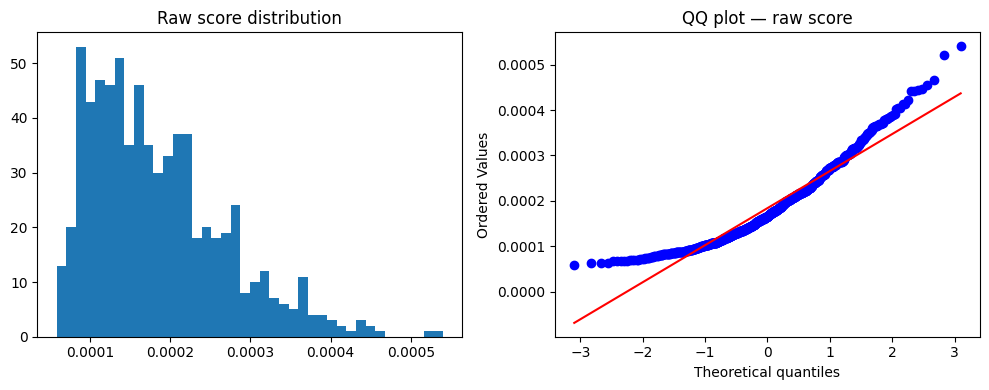

In [14]:
import scipy.stats as stats

all_scores = pd.concat([sdf["score"] for sdf in zone_sdfs.values()])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(all_scores, bins=40)
axes[0].set_title("Raw score distribution")
stats.probplot(all_scores, plot=axes[1])   # QQ plot
axes[1].set_title("QQ plot — raw score")
plt.tight_layout()


### Scale score globally

In [16]:
all_df = pd.concat(zone_sdfs.values())
all_df["score_scaled"] = (all_df["score"] - all_df["score"].mean()) / all_df["score"].std()
all_df["median_UMI_scaled"] = (all_df["median_UMI"] - all_df["median_UMI"].mean()) / all_df["median_UMI"].std()

# reprot the sacled version before
for zone in zone_sdfs:
    zone_sdfs[zone]["score_scaled"] = all_df.loc[all_df["zone"] == zone, "score_scaled"].values


all_df[SAMPLE_VARIABLE] = all_df.index

display(all_df)
print(all_df.groupby("zone")["score_scaled"].mean())  # should NOT all be ≈0

,sex,PC1,PC2,PC3,PC4,PC5,age,meanLogUMI,meanLogUMI2,log_n_cells,median_UMI,n_cells,score,zone,score_scaled,median_UMI_scaled,donor_id
MS652464,2.0,-0.0105,-0.0228,0.0033,0.0152,0.0020,70.0,10.816779,117.002704,4.043051,66798.0,57.0,0.000271,1,1.027346,-1.148063,MS652464
MS434915,1.0,-0.0105,-0.0233,0.0039,0.0165,0.0020,68.0,11.247429,126.504669,5.961005,79964.0,388.0,0.000144,1,-0.477062,-0.661760,MS434915
MS614721,1.0,0.0059,-0.0075,0.0103,0.0006,0.0002,65.0,11.248444,126.527485,6.001415,79300.0,404.0,0.000186,1,0.018787,-0.686285,MS614721
MD6670,1.0,-0.0099,-0.0233,0.0062,0.0181,-0.0005,40.0,11.228134,126.071000,6.566672,77437.0,711.0,0.000119,1,-0.771208,-0.755098,MD6670
MD6366,2.0,-0.0104,-0.0237,0.0039,0.0179,0.0005,31.0,11.397923,129.912645,6.790097,98195.0,889.0,0.000118,1,-0.785237,0.011626,MD6366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MD6670,1.0,-0.0099,-0.0233,0.0062,0.0181,-0.0005,40.0,11.635358,135.381545,4.060443,116496.5,58.0,0.000086,6,-1.166154,0.687615,MD6670
PT13645,1.0,-0.0106,-0.0237,0.0040,0.0189,0.0015,58.0,11.757669,138.242779,3.806662,134270.0,45.0,0.000083,6,-1.200580,1.344102,PT13645
PT13818,1.0,0.0190,-0.0035,0.0009,0.0047,0.0054,67.0,11.582402,134.152038,4.304065,111472.5,74.0,0.000100,6,-1.004294,0.502047,PT13818
PT13641,2.0,0.0221,-0.0013,0.0005,0.0018,0.0056,42.0,11.337943,128.548942,3.496508,95253.0,33.0,0.000069,6,-1.370618,-0.097041,PT13641


zone
1   -0.334836
2   -0.263535
3    0.056588
4    0.684873
5    0.044000
6   -0.334283
Name: score_scaled, dtype: float64


### Fit interaction model Age x Zone

In [17]:
# score_scaled ~ age * zone + median_UMI_scaled + (1 | donor_id)
    # solve non-indepence problem
    # calculte sinicnat metric for chneikin differce betnween zones
REF_ZONE = 4
model = smf.mixedlm(
    # explicit reference zone
    f"score_scaled ~ {AGE} * C({ZONE_COL}, Treatment(reference={REF_ZONE})) + median_UMI_scaled",
    data=all_df,
    groups=all_df[SAMPLE_VARIABLE],   # random intercept per donor
).fit()

print(model.summary())


                       Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         score_scaled
No. Observations:           706             Method:                     REML        
No. Groups:                 142             Scale:                      0.1077      
Min. group size:            1               Log-Likelihood:             -435.7390   
Max. group size:            6               Converged:                  Yes         
Mean group size:            5.0                                                     
------------------------------------------------------------------------------------
                                         Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                -1.577    0.182  -8.654 0.000 -1.934 -1.220
C(zone, Treatment(reference=4))[T.1]     -0.558    0.152  -3.681 0.000 -0.855 -0.261
C(zo

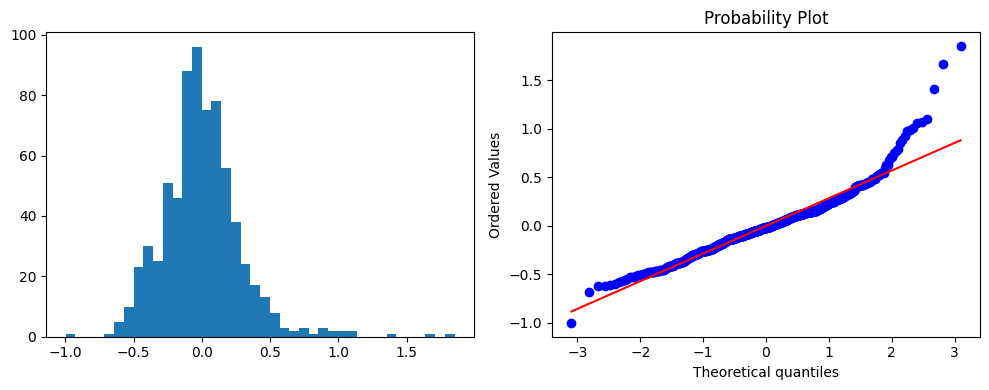

In [18]:
residuals = model.resid
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals, bins=40)
stats.probplot(residuals, plot=axes[1])
plt.tight_layout()


### Plot results

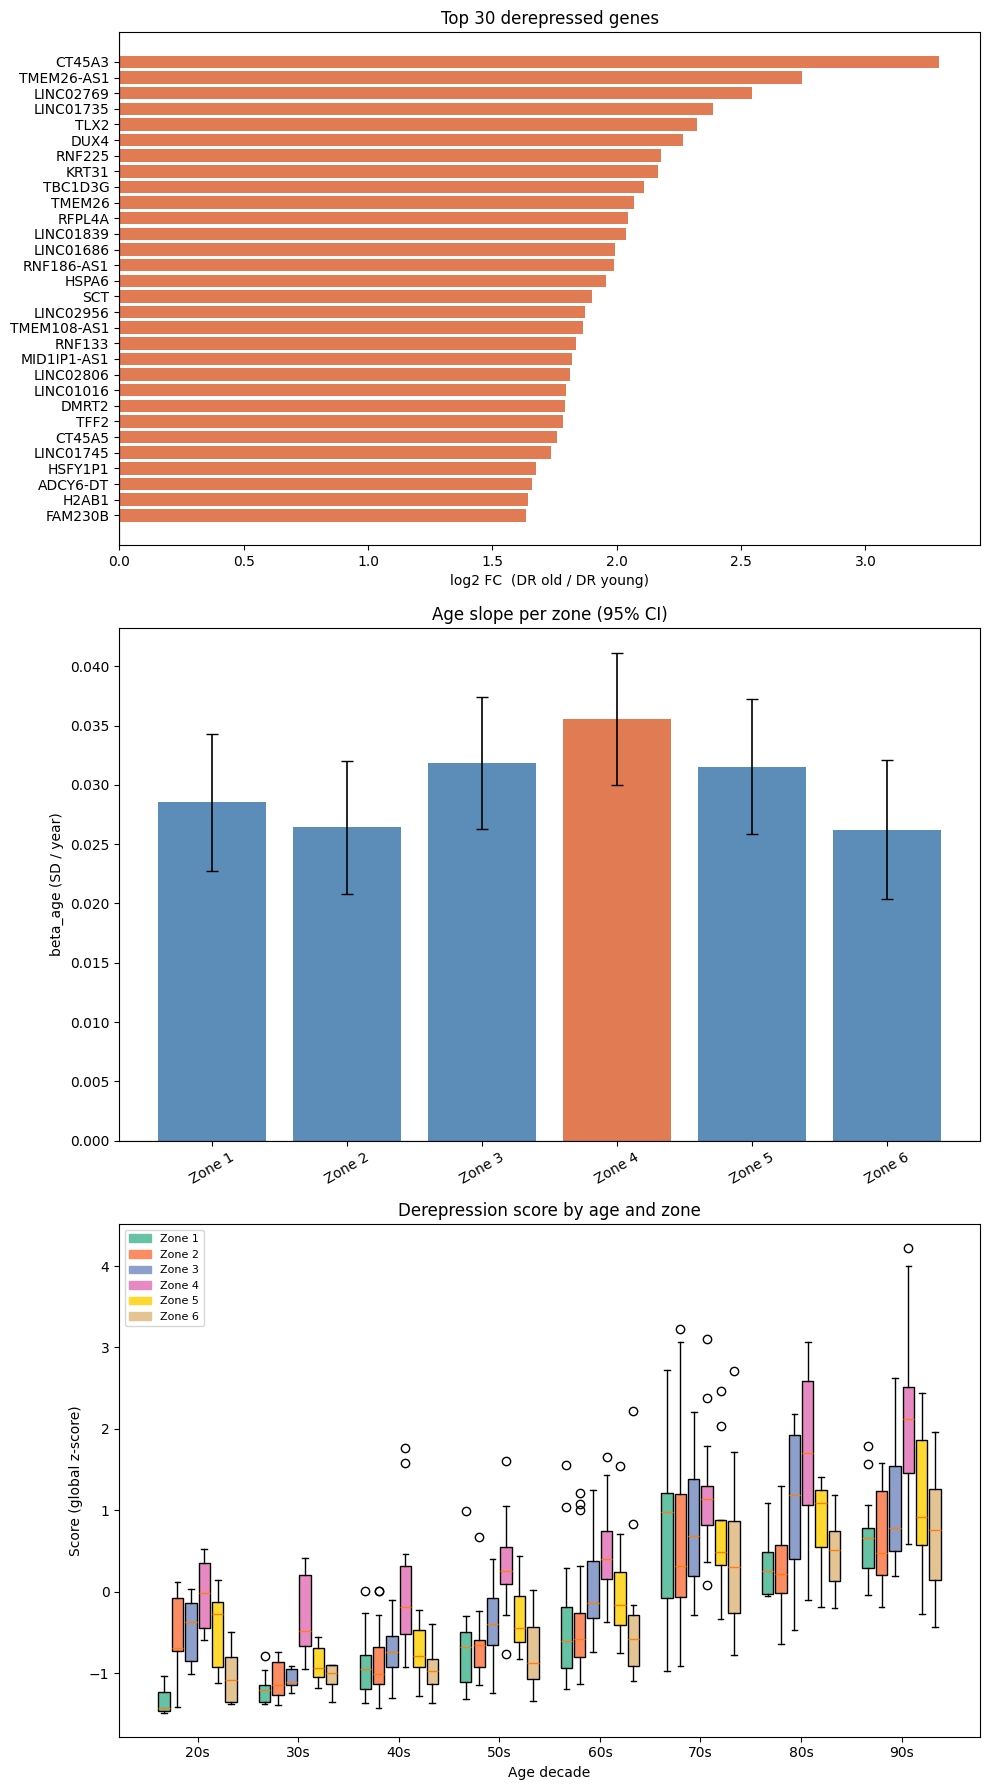

In [19]:
def plot_summary(derepressed_df, mixed_model, zone_sdfs, age_col, zone_col, ref_zone, top_n=30):
    fig, axes = plt.subplots(3, 1, figsize=(10, 18))

    # ── A: top derepressed genes by DR fold change ────────────────────────
    ax = axes[0]
    plot_df = derepressed_df.nlargest(top_n, "log2FC_DR")
    ax.barh(plot_df["gene"], plot_df["log2FC_DR"], color="#e07b54")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("log2 FC  (DR old / DR young)")
    ax.set_title(f"Top {top_n} derepressed genes")
    ax.invert_yaxis()

    # ── B: absolute age slope per zone with 95% CI via delta method ───────
    ax   = axes[1]
    p    = mixed_model.params
    vcov = mixed_model.cov_params()

    b_ref   = float(p[age_col])
    var_ref = float(vcov.loc[age_col, age_col])

    betas, lo95, hi95, labels = [], [], [], []

    for zone in sorted(zone_sdfs.keys()):
        if int(zone) == int(ref_zone):
            se = np.sqrt(var_ref)
            betas.append(b_ref);  lo95.append(b_ref - 1.96 * se);  hi95.append(b_ref + 1.96 * se)
        else:
            # name format: "age_of_death:C(zone, Treatment(reference=N))[T.Z]"
            match = [k for k in p.index if f"{age_col}:C({zone_col}" in k
                     and (f"[T.{zone}]" in k or f"[T.{int(zone)}]" in k)]
            if not match:
                continue
            term  = match[0]
            b_abs = b_ref + float(p[term])
            # Var(b_ref + b_int) = Var(b_ref) + Var(b_int) + 2*Cov(b_ref, b_int)
            var_abs = (var_ref + float(vcov.loc[term, term])
                       + 2 * float(vcov.loc[age_col, term]))
            se_abs  = np.sqrt(max(var_abs, 0))
            betas.append(b_abs);  lo95.append(b_abs - 1.96 * se_abs);  hi95.append(b_abs + 1.96 * se_abs)
        labels.append(str(int(zone)))

    x          = np.arange(len(labels))
    err_lo     = np.array(betas) - np.array(lo95)
    err_hi     = np.array(hi95)  - np.array(betas)
    bar_colors = ["#e07b54" if lbl == str(int(ref_zone)) else "#5b8db8" for lbl in labels]

    ax.bar(x, betas, color=bar_colors, yerr=[err_lo, err_hi], capsize=4,
           error_kw={"elinewidth": 1.2})
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x);  ax.set_xticklabels([f"Zone {l}" for l in labels])
    ax.set_ylabel("beta_age (SD / year)");  ax.set_title("Age slope per zone (95% CI)")
    ax.tick_params(axis="x", rotation=30)

    # ── C: boxplots score × age decade × zone ─────────────────────────────
    ax      = axes[2]
    zones   = sorted(zone_sdfs.keys())
    palette = dict(zip(zones, plt.cm.Set2(np.linspace(0, 0.8, len(zones)))))

    all_decades = sorted({
        str(int(age // 10 * 10)) + "s"
        for sdf in zone_sdfs.values()
        for age in sdf[age_col]
    })
    x_pos = np.arange(len(all_decades))
    width = 0.8 / len(zones)

    for i, zone in enumerate(zones):
        sdf = zone_sdfs[zone].copy()
        sdf["decade"] = (sdf[age_col] // 10 * 10).astype(int).astype(str) + "s"
        data = [sdf.loc[sdf["decade"] == d, "score_scaled"].values for d in all_decades]
        bp   = ax.boxplot(data,
                          positions=x_pos + (i - len(zones) / 2 + 0.5) * width,
                          widths=width * 0.85, patch_artist=True, manage_ticks=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(palette[zone])

    ax.set_xticks(x_pos);  ax.set_xticklabels(all_decades)
    ax.set_xlabel("Age decade");  ax.set_ylabel("Score (global z-score)")
    ax.set_title("Derepression score by age and zone")
    ax.legend(handles=[mpatches.Patch(color=palette[z], label=f"Zone {z}") for z in zones],
              fontsize=8)

    fig.tight_layout()
    return fig

fig = plot_summary(gene_derepressed, model, zone_sdfs,
                   age_col=AGE, zone_col=ZONE_COL, ref_zone=REF_ZONE)


### Why effect stirnger in 4?

In one sentence: Zone 4 spikes in the 90s because the few high-cell-count 90-year-old donors in BICAN happened to have tissue from predominantly ventral regions, and their cells all go to Zone 4 instead of being distributed across zones.

In [43]:
# 1. Are fewer old donors represented in dorsal zones?
for zone in sorted(bican.obs[ZONE_COL].unique()):
    age = bican.obs[bican.obs[ZONE_COL] == zone][AGE]
    print(f"Zone {zone}: n={len(age)}, mean age={age.mean():.1f}, old (>75)={( age>75).sum()}")

# 2. Are old dorsal samples smaller (fewer cells per donor)?
for zone in sorted(bican.obs[ZONE_COL].unique()):
    sub = bican.obs[bican.obs[ZONE_COL] == zone].groupby(SAMPLE_VARIABLE).agg(
        n_cells=(SAMPLE_VARIABLE, "count"), age=(AGE, "first")
    )
    print(f"Zone {zone}: corr(age, n_cells) = {sub['age'].corr(sub['n_cells']):.3f}")


Zone 1: n=26409, mean age=62.3, old (>75)=6481
Zone 2: n=31195, mean age=62.1, old (>75)=8419
Zone 3: n=26529, mean age=62.1, old (>75)=8501
Zone 4: n=88688, mean age=71.3, old (>75)=45929
Zone 5: n=22606, mean age=65.5, old (>75)=8923
Zone 6: n=11144, mean age=64.7, old (>75)=3987
Zone 1: corr(age, n_cells) = 0.051
Zone 2: corr(age, n_cells) = 0.057
Zone 3: corr(age, n_cells) = 0.036
Zone 4: corr(age, n_cells) = 0.406
Zone 5: corr(age, n_cells) = 0.233
Zone 6: corr(age, n_cells) = 0.218


/tmp/ipykernel_166770/1362855476.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub = bican.obs[bican.obs[ZONE_COL] == zone].groupby(SAMPLE_VARIABLE).agg(
/tmp/ipykernel_166770/1362855476.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub = bican.obs[bican.obs[ZONE_COL] == zone].groupby(SAMPLE_VARIABLE).agg(
/tmp/ipykernel_166770/1362855476.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub = bican.obs[bic

Expect .X is raw counts!
Normalizing...
Findingn HVGs...
Scaling...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Calculating PCA...
Calculating neighbors...
Calculating Umap...
Clutering...
Preprocessing done.


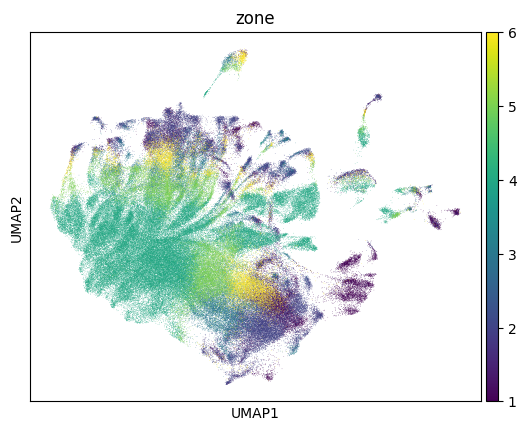

In [54]:
from utils import preprocessing
preprocessing.preprocess(bican, n_pcs_elbow=30, n_hvg=3000, hvg_batch_key=None, hvg_layer="counts", save_raw_counts=False, save_scaled=False, verbose=False)
sc.pl.umap(bican, color=ZONE_COL)

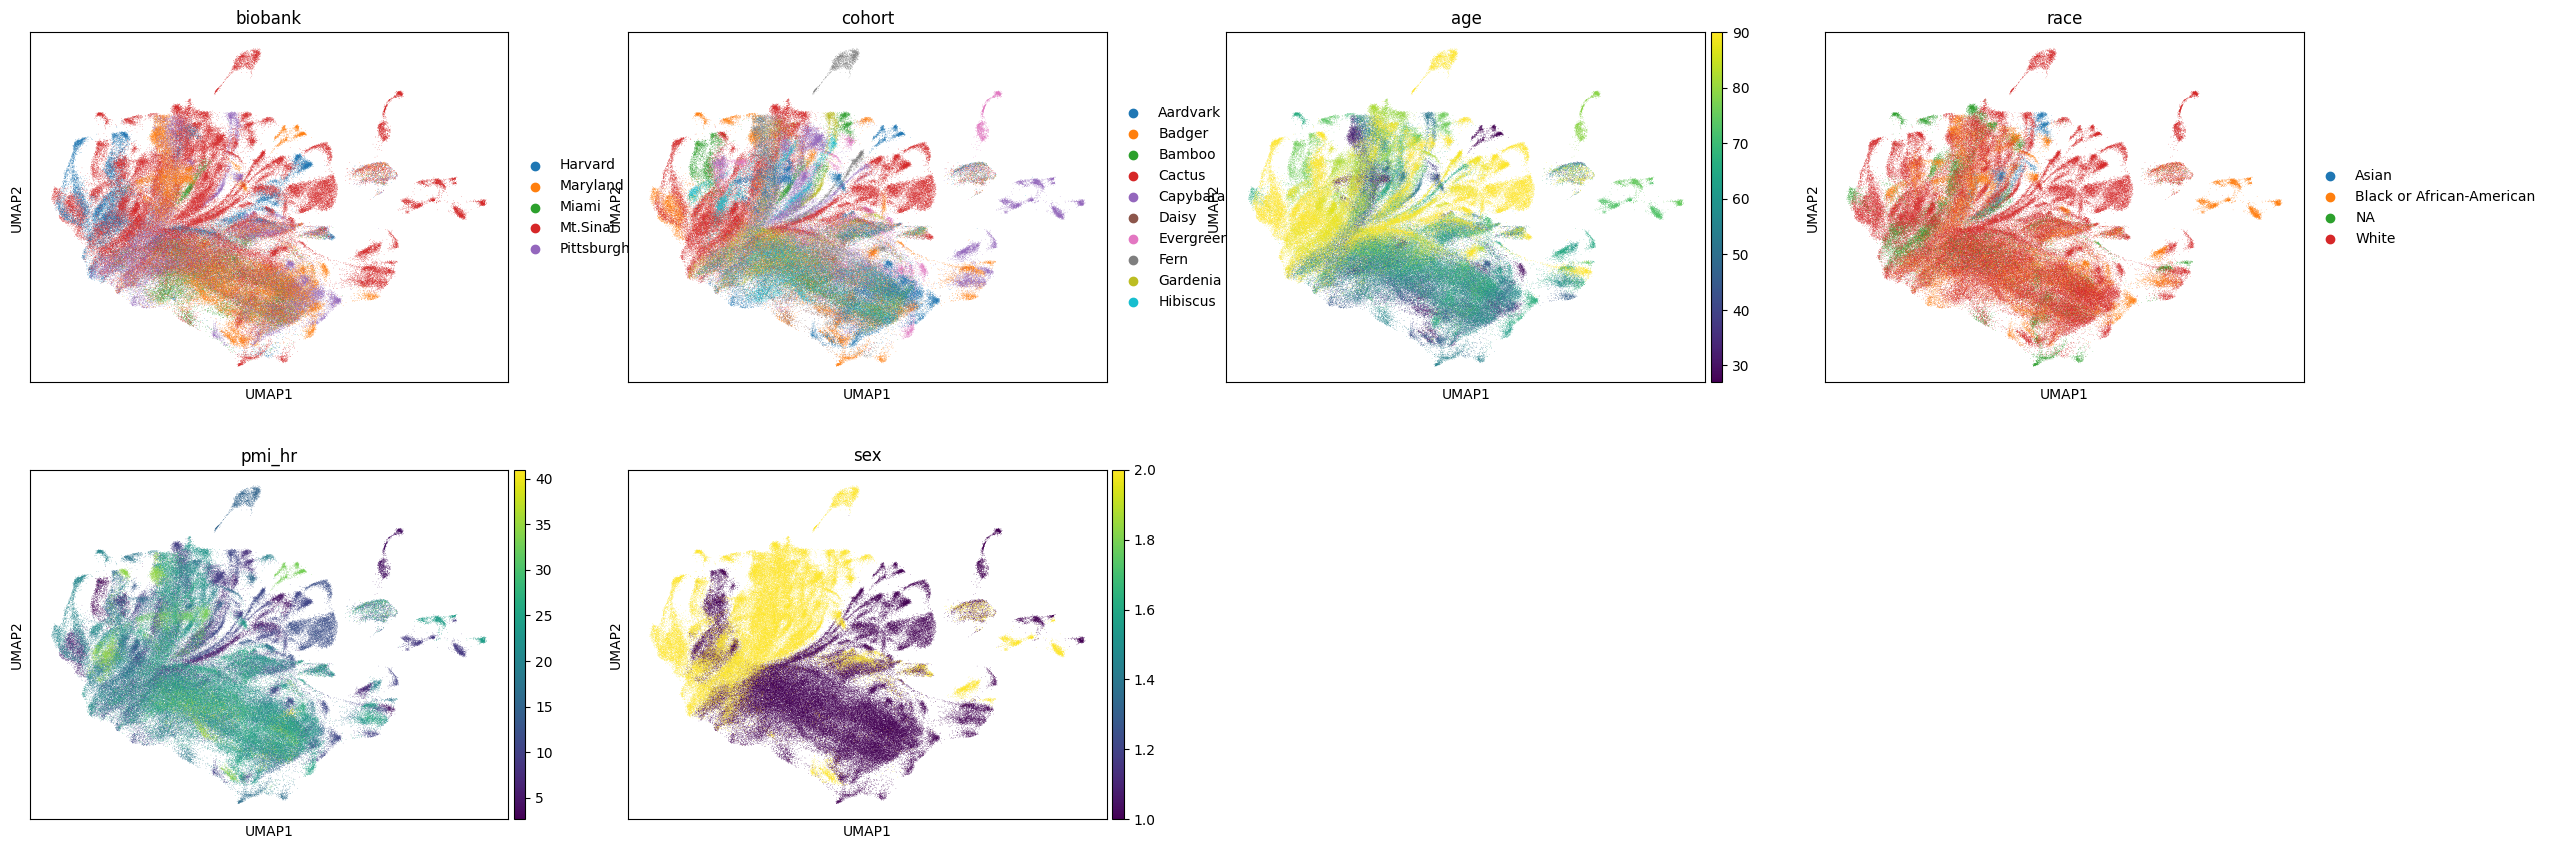

In [57]:
sc.pl.umap(bican, color=['biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex',])

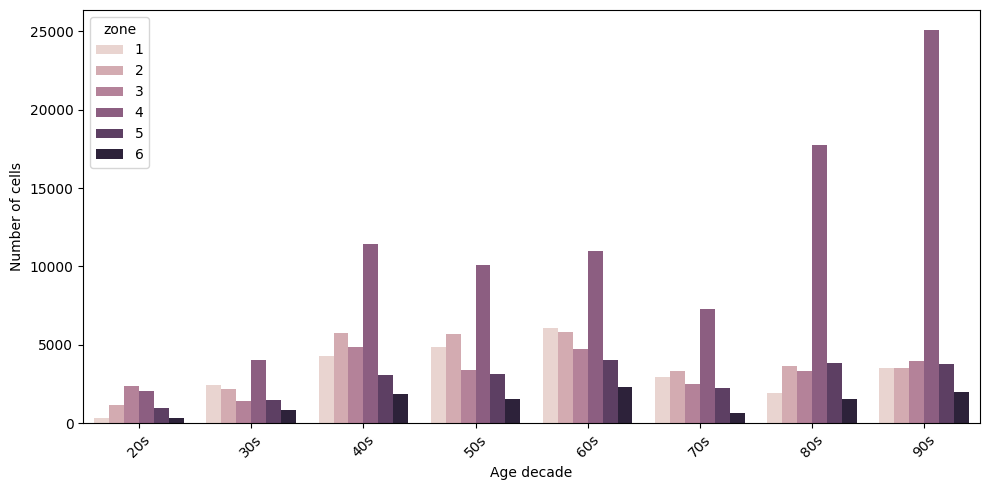

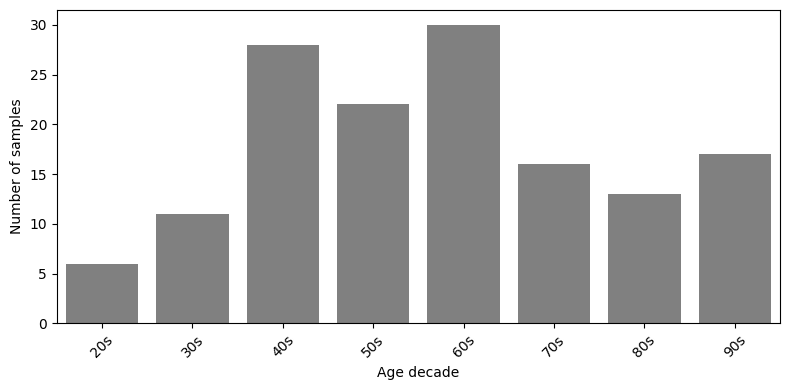

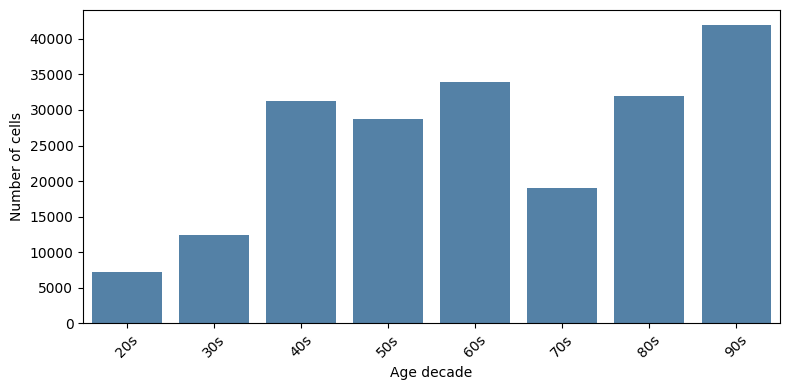

In [60]:
obs = bican.obs.copy()

obs["decade"] = (obs[AGE] // 10) * 10
# optional: make nicer labels
obs["decade_label"] = obs["decade"].astype(int).astype(str) + "s"

counts_df = (
    obs
    .groupby(["decade_label", ZONE_COL])
    .size()
    .reset_index(name="n_cells")
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.barplot(
    data=counts_df,
    x="decade_label",
    y="n_cells",
    hue=ZONE_COL
)

plt.ylabel("Number of cells")
plt.xlabel("Age decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sample_counts_df = (
    obs
    .groupby("decade_label")[SAMPLE_VARIABLE]
    .nunique()
    .reset_index(name="n_samples")
)

plt.figure(figsize=(8, 4))



sns.barplot(
    data=sample_counts_df,
    x="decade_label",
    y="n_samples",
    color="gray"
)

plt.ylabel("Number of samples")
plt.xlabel("Age decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

cell_counts_df = (
    obs
    .groupby("decade_label")
    .size()
    .reset_index(name="n_cells")
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=cell_counts_df,
    x="decade_label",
    y="n_cells",
    color="steelblue"
)

plt.ylabel("Number of cells")
plt.xlabel("Age decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

0.23432447777175855


/tmp/ipykernel_166770/995238917.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bican.obs.groupby(SAMPLE_VARIABLE)[ZONE_COL]


<Axes: xlabel='age', ylabel='zone4_frac'>

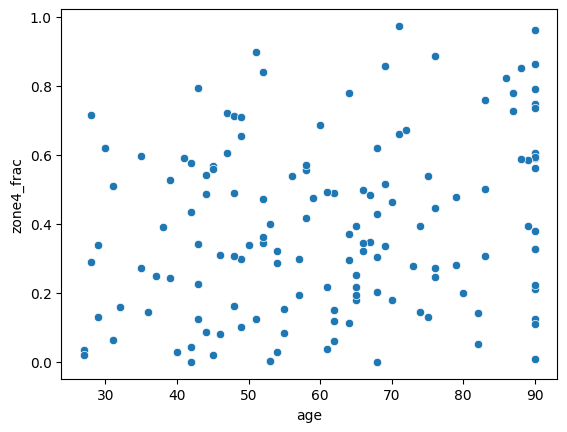

In [58]:
# fraction of each donor's cells that fall in Zone 4
zone4_frac = (
    bican.obs.groupby(SAMPLE_VARIABLE)[ZONE_COL]
    .apply(lambda x: (x == 4).mean())
    .rename("zone4_frac")
)
age_per_donor = bican.obs.drop_duplicates(SAMPLE_VARIABLE).set_index(SAMPLE_VARIABLE)[AGE]

df_check = pd.concat([zone4_frac, age_per_donor], axis=1)
print(df_check["zone4_frac"].corr(df_check[AGE]))
sns.scatterplot(data=df_check, x=AGE, y="zone4_frac")


In [61]:
cells_per_donor = bican.obs.groupby(SAMPLE_VARIABLE).size().rename("n_cells_total")
df_check = pd.concat([zone4_frac, age_per_donor, cells_per_donor], axis=1)

# is total cells per donor correlated with age?
print(df_check["n_cells_total"].corr(df_check[AGE]))

# who are the big outliers?
df_check[df_check["zone4_frac"] > 0.7].sort_values("n_cells_total", ascending=False).head(10)


0.4018875491721645


/tmp/ipykernel_166770/3243298196.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_per_donor = bican.obs.groupby(SAMPLE_VARIABLE).size().rename("n_cells_total")


,zone4_frac,age,n_cells_total
donor_id,,,
MS986638,0.852331,88,6650
MS966845,0.863338,90,5949
MLS04249,0.746558,90,4431
MLS08066,0.735357,90,3295
UMBEB24009,0.711011,49,2661
MS68083,0.963110,90,2521
MLS02599,0.790388,90,2476
MS792437,0.760733,83,1747
PT13994,0.897372,51,1598


/tmp/ipykernel_166770/2120963722.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_pz   = bican.obs.groupby([SAMPLE_VARIABLE, ZONE_COL]).size().unstack(fill_value=0)


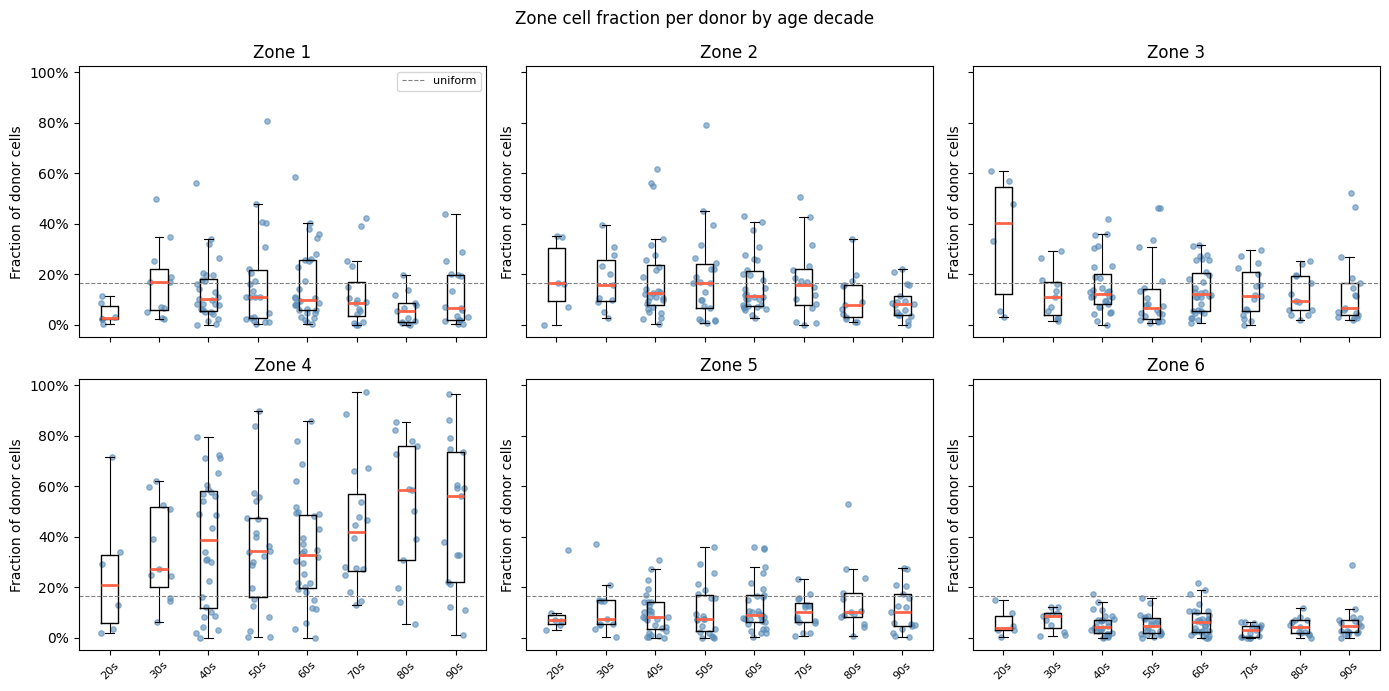

In [77]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# build per-donor zone fraction table
cells_pz   = bican.obs.groupby([SAMPLE_VARIABLE, ZONE_COL]).size().unstack(fill_value=0)
frac_pz    = cells_pz.div(cells_pz.sum(axis=1), axis=0)
age_donor  = bican.obs.drop_duplicates(SAMPLE_VARIABLE).set_index(SAMPLE_VARIABLE)[AGE]
frac_pz["decade"] = (age_donor // 10 * 10).astype(int).astype(str) + "s"

zones   = sorted(bican.obs[ZONE_COL].unique())
decades = sorted(frac_pz["decade"].unique())
x_pos   = {d: i for i, d in enumerate(decades)}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True, sharex=True)
axes = axes.flatten()

for ax, zone in zip(axes, zones):
    for decade in decades:
        vals = frac_pz.loc[frac_pz["decade"] == decade, zone].values
        jitter = np.random.uniform(-0.25, 0.25, size=len(vals))
        ax.scatter(x_pos[decade] + jitter, vals, s=15, alpha=0.6, color="#5b8db8")
        ax.boxplot(vals, positions=[x_pos[decade]], widths=0.35,
                   patch_artist=False, manage_ticks=False,
                   medianprops=dict(color="tomato", linewidth=2),
                   whiskerprops=dict(linewidth=0.8),
                   capprops=dict(linewidth=0.8),
                   flierprops=dict(marker="", linewidth=0))

    ax.set_title(f"Zone {zone}")
    ax.set_xticks(range(len(decades)))
    ax.set_xticklabels(decades, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylabel("Fraction of donor cells")
    ax.axhline(1/len(zones), color="grey", lw=0.8, linestyle="--", label="uniform")

axes[0].legend(fontsize=8)
fig.suptitle("Zone cell fraction per donor by age decade", fontsize=12)
fig.tight_layout()
plt.show()


### Chekc if derepressed genes are enriched for polycomb

In [38]:
gene_derepressed.nlargest(50, "log2FC_DR")

,gene,beta_age,pval,mean_dr_Y,mean_dr_O,pval_adj,log2FC_DR
30,CT45A3,2.654038e+00,0.000000e+00,0.000099,0.001854,0.000000e+00,3.295768
46,TMEM26-AS1,2.154263e+00,0.000000e+00,0.005781,0.039283,0.000000e+00,2.743562
56,LINC02769,1.878762e+00,0.000000e+00,0.011454,0.067215,0.000000e+00,2.542534
58,LINC01735,1.791603e+00,0.000000e+00,0.031681,0.166152,0.000000e+00,2.387158
63,TLX2,1.733594e+00,0.000000e+00,0.000504,0.002923,0.000000e+00,2.324539
98,DUX4,1.295058e+00,0.000000e+00,0.006267,0.030521,0.000000e+00,2.265732
12,RNF225,3.670800e+00,1.628039e-203,0.000004,0.000371,2.894476e-203,2.178815
13,KRT31,3.569161e+00,0.000000e+00,0.000037,0.000514,0.000000e+00,2.164105
48,TBC1D3G,2.057759e+00,2.954579e-10,0.000034,0.000476,3.399050e-10,2.108185
64,TMEM26,1.731514e+00,0.000000e+00,0.016497,0.069532,0.000000e+00,2.068809


In [35]:
_CT_ANTIGENS = [
    # CT45
    "CT45A1", "CT45A2", "CT45A3", "CT45A4", "CT45A5", "CT45A6", "CT45A7",
    # MAGE-A
    "MAGEA1", "MAGEA2", "MAGEA2B", "MAGEA3", "MAGEA4", "MAGEA6",
    "MAGEA9", "MAGEA9B", "MAGEA10", "MAGEA11", "MAGEA12",
    # MAGE-B/C
    "MAGEB1", "MAGEB2", "MAGEB3", "MAGEB4", "MAGEB6",
    "MAGEC1", "MAGEC2", "MAGEC3",
    # GAGE
    "GAGE1", "GAGE2A", "GAGE2B", "GAGE2C", "GAGE2D", "GAGE2E", "GAGE12I",
    # SSX
    "SSX1", "SSX2", "SSX4", "SSX4B", "SSX5",
    # NY-ESO-1 / CTAG
    "CTAG1A", "CTAG1B", "CTAG2",
    # PAGE
    "PAGE1", "PAGE2", "PAGE2B", "PAGE3", "PAGE4", "PAGE5",
    # XAGE
    "XAGE1A", "XAGE1B", "XAGE2", "XAGE3",
    # SPANX
    "SPANXA1", "SPANXA2", "SPANXB1", "SPANXB2", "SPANXC", "SPANXD",
    # RFPL
    "RFPL1", "RFPL2", "RFPL3", "RFPL4A", "RFPL4AL1",
    # DUX
    "DUX4", "DUX4L1", "DUXA",
    # other
    "PRAME", "NXF2", "HORMAD1", "HORMAD2", "DAZL",
    "BRDT", "DDX43", "OIP5", "CTCFL", "FATE1",
    "RNF133", "RNF148", "HSFY1", "HSFY2",
]

prc2_genes = {
    "supp_table_3_PRC2_paper": [
        'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
        'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
        'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', 'LECT1', 'PYGL', 'DMRT3', 'TFAP2C',
        'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1', 'AMN', 'TMEM30B', 'IRX3',
        'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3', 'SIX6', 'TBX2', 'CD44',
        'ASB4', 'SCARF2', 'VGLL2', 'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10',
        'HOXA9', 'HOXC10', 'SLC6A5', 'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9',
        'HOXB7', 'HOXB8', 'MNX1', 'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2',
        'LUM', 'GATA2', 'PMAIP1', 'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1',
        'HMX1', 'TBX3', 'FOXA1', 'EBF3', 'HOXB13', 'EN1', 'HOXD13', 'LHX5',
        'HOXA7', 'HOXC5', 'NEUROD1', 'TFAP2A', 'HOXB5', 'SHOX2', 'TFAP2B',
        'NEUROD2', 'TLX1', 'TNNT2', 'SULT1A1', 'VAX2', 'HOXD11', 'CDKN1A',
        'NEUROG2', 'EOMES', 'PLIN4', 'TPBG', 'SSTR3', 'DLK1', 'PRDM8', 'HOXA4',
        'NRN1', 'VSX2', 'GFI1', 'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2',
        'MATN2', 'HOXB3', 'KRT1', 'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2',
        'HEYL', 'GSTA3', 'NKX2-5', 'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4',
        'SIX1', 'GRP', 'COL23A1', 'CIRBP', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
        'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'ISLR', 'ASB5', 'MYCL1', 'SDC1',
        'GATA4', 'BEND5', 'FXYD7', 'FOXL2', 'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25',
        'CLDN3', 'SLC6A7', 'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD',
        'GNA13', 'ALX1', 'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1',
        'CPA6', 'DMRT2', 'CPNE6', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
        'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2',
    ],  # mouse-specific IDs removed (RIK, GM*, ZFP644, TRP53I11, SERPINA3N, CES1D, ALDH1A7, etc.)

    "death_promoting_silenced_by_prc2": ["PMAIP1", "BID", "CDKN2A", "CDKN2B", "CCND1", "WT1", "IGFBP3", "TP73", "CDKN1A"],
    "msn_identity_genes_downregulated": ["DRD1", "DRD2", "ADORA2A", "PDE10A", "ARPP21", "RGS9", "FOXP1", "RXRG", "BCL11B", "GPR6", "KCND2", "PPP1R1B"],
    "purkinje_cell_genes_lost":         ["CALB1", "PCP2", "PVALB", "RORA", "FXN", "EBF3", "LHX1", "LHX5"],
    "hox":           ["HOXA3", "HOXA4", "HOXA5", "HOXA7", "HOXA9", "HOXA10", "HOXB2", "HOXB3", "HOXB5", "HOXB6", "HOXB7", "HOXB8", "HOXB13", "HOXC4", "HOXC5", "HOXC8", "HOXC10", "HOXD3", "HOXD8", "HOXD9", "HOXD10", "HOXD11", "HOXD13"],
    "t_box":         ["EOMES", "TBX2", "TBX3", "TBX20"],
    "gata":          ["GATA2", "GATA3", "GATA4", "GATA6"],
    "cardiac":       ["NKX2-5", "HAND2", "TWIST1", "TNNT2"],
    "neuronal":      ["NEUROD1", "NEUROD2", "NEUROG2", "NRN1"],
    "lim":           ["LHX1", "LHX5", "LHX9"],
    "forkhead":      ["FOXA1", "FOXD1", "FOXD2", "FOXL2", "FOXL2OS"],
    "other_tfs":     ["ZIC2", "EN1", "ONECUT1", "BARX1", "SFMBT2", "BHLHE22", "DLX4", "EBF3", "FOXF1", "GRHL1", "IRX2", "IRX3", "IRX5", "LBX1", "LMX1B", "NKX3-1", "NKX6-1", "PAX1", "PAX3", "PAX6", "SHOX2", "SIX1", "SIX2", "SIX6", "TLX1", "CBX4", "DMRT2", "DMRT3", "DMRTA2", "VSX2", "MNX1", "TFAP2A", "MYCL1", "HEYL", "DAB1"],
    "non_tf_upregulated": ["SFRP2", "DLK1", "NTF3", "FBN1", "MATN2", "COL6A2", "COL23A1", "C1QTNF1", "COLEC11", "ISLR", "TPBG", "SDC1", "SH2B2", "GNA13", "RGNEF", "DAB1", "SSTR3", "RIPK4", "PLIN4", "CIRBP", "HEYL", "GRP", "PYGL", "ALDOC", "GSTA3", "S100A8", "S100A10", "SLC6A7", "SLCO4A1", "MFSD4", "CLDN3", "TMEM30B", "AMN", "CPA6", "DSP", "CYBRD1", "KAZALD1", "MMD", "ACY3", "GALNTL1", "SERPINB1", "SERPINA3"],
    "ct_antigens_all": _CT_ANTIGENS,
}


In [ ]:
import derepression_functions as drf

cmh_input = full_results.copy()
cmh_input["perm_padj"] = np.where(
    (cmh_input["pval_adj"].fillna(0) < 0.05) &
    (cmh_input["beta_age"] > 0) &
    (cmh_input["log2FC_DR"] > 0.5),
    cmh_input["pval_adj"].fillna(0),
    1.0,
)
cmh_input["overall_detect"] = (cmh_input["mean_dr_Y"] + cmh_input["mean_dr_O"]) / 2

universe_genes = set(cmh_input["gene"])

cmh_results = []
for category, gene_list in prc2_genes.items():
    gene_list_filtered = [g for g in gene_list if g[
        'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
        'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
        'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', 'LECT1', 'PYGL', 'DMRT3', 'TFAP2C',
        'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1', 'AMN', 'TMEM30B', 'IRX3',
        'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3', 'SIX6', 'TBX2', 'CD44',
        'ASB4', 'SCARF2', 'VGLL2', 'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10',
        'HOXA9', 'HOXC10', 'SLC6A5', 'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9',
        'HOXB7', 'HOXB8', 'MNX1', 'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2',
        'LUM', 'GATA2', 'PMAIP1', 'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1',
        'HMX1', 'TBX3', 'FOXA1', 'EBF3', 'HOXB13', 'EN1', 'HOXD13', 'LHX5',
        'HOXA7', 'HOXC5', 'NEUROD1', 'TFAP2A', 'HOXB5', 'SHOX2', 'TFAP2B',
        'NEUROD2', 'TLX1', 'TNNT2', 'SULT1A1', 'VAX2', 'HOXD11', 'CDKN1A',
        'NEUROG2', 'EOMES', 'PLIN4', 'TPBG', 'SSTR3', 'DLK1', 'PRDM8', 'HOXA4',
        'NRN1', 'VSX2', 'GFI1', 'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2',
        'MATN2', 'HOXB3', 'KRT1', 'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2',
        'HEYL', 'GSTA3', 'NKX2-5', 'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4',
        'SIX1', 'GRP', 'COL23A1', 'CIRBP', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
        'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'ISLR', 'ASB5', 'MYCL1', 'SDC1',
        'GATA4', 'BEND5', 'FXYD7', 'FOXL2', 'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25',
        'CLDN3', 'SLC6A7', 'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD',
        'GNA13', 'ALX1', 'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1',
        'CPA6', 'DMRT2', 'CPNE6', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
        'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2',
    ] in universe_genes]
    n_in_universe = len(gene_list_filtered)
    if n_in_universe < 3:
        continue

    n_bins = max(3, min(20, n_in_universe // 3))

    res = drf.polycomb_enrichment_cmh(
        results_df     = cmh_input,
        polycomb_genes = gene_list_filtered,
        fdr_alpha      = 0.05,
        n_bins         = n_bins,
    )

    cmh_results.append({
        "category"     : category,
        "n_in_universe": n_in_universe,
        "n_sig_overlap": res["overlap"],
        "odds_ratio"   : round(res["odds_ratio"], 3) if res["odds_ratio"] is not None else np.nan,
        "pval"         : res["pval"],
        "n_strata"     : res["n_strata"],
        "overlap_genes": res["overlap_genes"],
    })

cmh_df = pd.DataFrame(cmh_results)
_, cmh_df["pval_adj"], _, _ = multipletests(cmh_df["pval"], method="fdr_bh")
cmh_df = cmh_df.sort_values("pval_adj").reset_index(drop=True)

cmh_df["significant"] = cmh_df["pval_adj"] < 0.05

display(cmh_df[["category", "n_in_universe", "n_sig_overlap",
                "odds_ratio", "pval", "pval_adj", "n_strata", "overlap_genes", "significant"]])


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/statsmodels/stats/contingency_tables.py:1077: RuntimeWarning: divide by zero encountered in scalar divide
  odds_ratio = np.sum(self._ad / self._n) / np.sum(self._bc / self._n)


,category,n_in_universe,n_sig_overlap,odds_ratio,pval,pval_adj,n_strata,overlap_genes,significant
0,lim,3,3,inf,9.071111e-09,1.179244e-07,3,"[LHX5, LHX9, LHX1]",True
1,purkinje_cell_genes_lost,4,2,18.041,1.334450e-04,8.673924e-04,3,"[LHX5, LHX1]",True
2,neuronal,4,2,12.432,8.014390e-04,3.472902e-03,3,"[NEUROD2, NEUROG2]",True
3,death_promoting_silenced_by_prc2,7,2,6.610,6.093831e-03,1.980495e-02,3,"[CDKN1A, CDKN2B]",True
4,ct_antigens_all,63,11,1.988,2.096279e-02,5.450325e-02,19,"[HSFY1, RNF133, XAGE1B, RFPL4A, CT45A5, RFPL4A...",False
5,cardiac,4,1,3.101,1.589009e-01,3.442854e-01,3,[TNNT2],False
6,supp_table_3_PRC2_paper,134,17,1.237,2.096666e-01,3.893808e-01,19,"[HOXA9, LHX5, TNNT2, CDKN1A, HOXD11, GRP, LUM,...",False
7,non_tf_upregulated,24,2,1.229,3.898236e-01,6.162334e-01,8,"[GRP, SERPINA3]",False
8,other_tfs,29,3,1.123,4.266231e-01,6.162334e-01,9,"[NKX6-1, DMRT2, IRX5]",False
9,t_box,4,0,0.000,7.292332e-01,7.666935e-01,3,[],False
